# **Gaussian Mixture Models (GMMs)**

Gaussian Mixture Models (GMMs) are powerful probabilistic models widely used in clustering, density estimation, and unsupervised learning. Here's a comprehensive breakdown of all key concepts:

---

## **1. What is a Gaussian Mixture Model?**
A GMM assumes data is generated from **multiple Gaussian (normal) distributions** mixed together. It's a **soft clustering** algorithm where each point can belong to multiple clusters with different probabilities.

### **Key Characteristics**
- **Probabilistic**: Assigns probabilities to cluster memberships.
- **Flexible**: Can model complex, non-spherical data distributions.
- **Generative**: Can generate new samples similar to training data.

---

## **2. Mathematical Foundations**

### **Single Gaussian Distribution**
For a single Gaussian (normal) distribution:

$$
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

- **μ**: Mean (center)  
- **σ²**: Variance (spread)

### **GMM Formula**
A GMM combines **K Gaussians**:

$$
p(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)
$$

- **πₖ**: Mixing weight (probability of cluster *k*), where \(\sum_{k=1}^K \pi_k = 1\)  
- **μₖ, Σₖ**: Mean and covariance matrix of the *k*-th Gaussian

---

## **3. How GMM Works (Step-by-Step)**

### **Step 1: Initialization**
- Randomly assign means (μₖ), covariances (Σₖ), and mixing weights (πₖ)

### **Step 2: Expectation-Maximization (EM) Algorithm**
GMMs are trained using the **EM algorithm**, which iteratively refines parameters:

#### **E-Step (Expectation)**
Compute the **posterior probability** (responsibility) that data point *xᵢ* belongs to cluster *k*:

$$
\gamma_{ik} = \frac{\pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(x_i | \mu_j, \Sigma_j)}
$$

- \(\gamma_{ik}\) = Probability that *xᵢ* is in cluster *k*

#### **M-Step (Maximization)**
Update parameters using weighted averages:

$$
\mu_k = \frac{\sum_{i=1}^N \gamma_{ik} x_i}{\sum_{i=1}^N \gamma_{ik}}
$$

$$
\Sigma_k = \frac{\sum_{i=1}^N \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_{i=1}^N \gamma_{ik}}
$$

$$
\pi_k = \frac{\sum_{i=1}^N \gamma_{ik}}{N}
$$

### **Step 3: Convergence Check**
Repeat E and M steps until parameters stabilize (log-likelihood stops improving)

---

## **4. Key Concepts in GMM**

### **(1) Soft vs. Hard Clustering**
- **Hard Clustering (K-means)**: Each point belongs to **one cluster**
- **Soft Clustering (GMM)**: Each point has **probabilities** of belonging to all clusters

### **(2) Covariance Matrix (Σ) Shapes**
The **Σ** matrix defines cluster shape:
- **Spherical**: Equal variance in all directions (like K-means)
- **Diagonal**: Different variances per dimension (axis-aligned ellipses)
- **Full**: Arbitrarily oriented ellipses (most flexible)

### **(3) Choosing the Number of Clusters (K)**
- **Bayesian Information Criterion (BIC)**: Penalizes model complexity
- **Akaike Information Criterion (AIC)**: Balances fit and simplicity

---

## **5. Applications of GMM**

| **Application**        | **Description**                                                                 |
|------------------------|---------------------------------------------------------------------------------|
| **Clustering**         | Grouping data points into meaningful categories (e.g., customer segmentation)   |
| **Density Estimation** | Modeling the probability distribution of data (e.g., anomaly detection)         |
| **Image Segmentation** | Separating foreground/background in images                                      |
| **Speech Recognition** | Modeling phoneme distributions in audio signals                                 |

---

## **6. GMM vs. K-means**

| **Feature**         | **GMM**                              | **K-means**                        |
|---------------------|---------------------------------------|------------------------------------|
| **Cluster Shape**   | Elliptical (flexible)                 | Spherical (rigid)                  |
| **Membership**      | Probabilistic (soft)                  | Deterministic (hard)               |
| **Convergence**     | Slower (EM iterations)                | Faster (Lloyd’s algorithm)         |
| **Outlier Handling**| Better (probabilistic)                | Poor (sensitive to outliers)       |

---

## **7. Implementing GMM in Python**

```python
from sklearn.mixture import GaussianMixture

# Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type='full')
gmm.fit(X)

# Predict cluster probabilities
probs = gmm.predict_proba(X)  # Soft clustering

# Generate new samples
synthetic_data = gmm.sample(100)[0]  # Useful for generative tasks


## **8. Limitations of GMM**
- **Assumes Gaussianity**: Struggles with non-Gaussian data.
- **Sensitive to Initialization**: EM can converge to local optima.
- **Computationally Expensive**: For high-dimensional data.

---

## **9. Exam/Interview Questions**
1. **Q**: Why use GMM instead of K-means?  
   **A**: GMM allows soft clustering and handles non-spherical clusters.

2. **Q**: How does EM work in GMM?  
   **A**: E-step computes responsibilities; M-step updates μ, Σ, π.

3. **Q**: How to choose *K* in GMM?  
   **A**: Use BIC/AIC or cross-validation.

---

## **10. Key Takeaways**
- GMMs model data as a mixture of Gaussians.
- EM algorithm optimizes parameters iteratively.
- Useful for soft clustering, density estimation, and generative tasks.
- More flexible than K-means but computationally heavier.


Log Likelihood: -1.4978006547501472
AIC: 483.34019642504416
BIC: 534.5209964246806


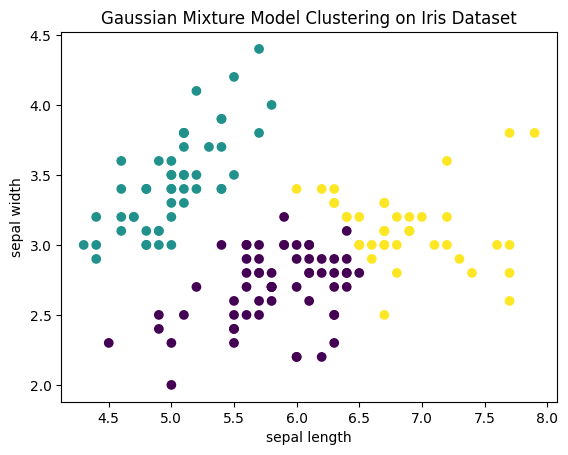

In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import datasets
from sklearn.mixture import GaussianMixture

iris = datasets.load_iris()
X = iris.data[:, :2]

gmm= GaussianMixture(n_components=3)
gmm.fit(X)
labels = gmm.predict(X)

# Calculate log likelihood of the model
log_likelihood = gmm.score(X)
print(f"Log Likelihood: {log_likelihood}")

# Calculate AIC and BIC values
aic = gmm.aic(X)
bic = gmm.bic(X)
print(f"AIC: {aic}")
print(f"BIC: {bic}")

# Plot the data-points with color coded clusters
plt.scatter(X[:,0],X[:,1],c=labels)
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('Gaussian Mixture Model Clustering on Iris Dataset')
plt.show()

# 📊 **GMMs – Evaluation Metrics** 

In this session, we'll explore how to evaluate **Gaussian Mixture Models** using three key metrics. Although more metrics exist, understanding these three will give you a solid foundation.

## 🌸 Dataset Used: The Iris Dataset

We chose the **Iris dataset** because:

* It contains **3 species**, so the expected number of clusters is 3.
* It's a popular benchmark to evaluate clustering models since we know the true labels.

## ⚙️ Steps Followed:

1. **Libraries Imported**: NumPy, Matplotlib, and Scikit-learn.
2. **Iris Data Loaded**.
3. **Features Selected**: We used **only 2 features** (columns) for simplicity.
4. **Model Created**: `GaussianMixture(n_components=3)` from `sklearn.mixture`.
5. **Model Fitted** on selected data.
6. **Cluster Labels Predicted**.
7. **Clusters Visualized** using color-coded plots.

## 🧠 What Are Clustering Metrics?

Metrics help answer:

* How well are the clusters formed?
* Are the clusters meaningful?
* Are they overlapping too much?

## 📏 Metric 1: **Log-Likelihood (log-likelihood)**

### ✅ What is it?

* Tells us **how well the model fits the data**.
* A higher (more positive) value means better clustering.
* If it's too low or negative → poor clustering.

### 🧠 Analogy:

Think of **log-likelihood** as how confident the model is that the points belong to their assigned clusters.

### 🧮 What's Happening Behind the Scenes?

* First, the model computes **likelihood**: probability of points being in a cluster.
* Then, it takes the **log of that likelihood** (to make it manageable).
* In sklearn: `.score()` method returns the **average log-likelihood**.

> If `log-likelihood > 0`: Clusters are likely **good**.
> If `log-likelihood < 0`: Clusters are likely **poor**.

## ⚖️ Problem with Log-Likelihood?

* It doesn't consider **model complexity**.
* It may rate a **very complex model** highly even if it's not a good general model.

Hence, we use **two more metrics** that penalize complexity.

## 📉 Metric 2: **AIC – Akaike Information Criterion**

### ✅ What is AIC?

* Measures how **well the model fits** while also considering **its complexity**.
* Lower AIC = **better fit**.

### 🧠 Analogy:

Imagine choosing between two cars:

* One has **fancy features** (complex), the other is **simple but efficient**.
* AIC helps pick the car that's **effective without overdoing** the features.

### ✅ Ideal AIC:

* Should be **as low as possible**.
* A balance between accuracy and simplicity.

## 📊 Metric 3: **BIC – Bayesian Information Criterion**

### ✅ What is BIC?

* Like AIC but derived from **Bayesian probability**.
* Penalizes complexity more heavily than AIC.
* Also prefers **simpler models with better fit**.

### 🧠 Analogy:

Think of flipping a coin. Based on the outcome and prior beliefs, BIC calculates the most probable explanation with the **least assumptions**.

> Lower BIC = model fits well **without being too complex**.

## 💡 Summary of All Three Metrics:

| Metric         | Goal                   | Ideal Value     | Notes                          |
| -------------- | ---------------------- | --------------- | ------------------------------ |
| Log-Likelihood | Fit to data            | High / Positive | Doesn't account for complexity |
| AIC            | Fit + simplicity       | Low             | Prefers simpler models         |
| BIC            | Fit + stronger penalty | Low             | Based on Bayesian probability  |

## 🔁 Why Not Rely on Just One?

* **Log-likelihood** might be high for overly complex models.
* **AIC** and **BIC** help control that by introducing penalties for unnecessary complexity.
* Together, they form a strong **evaluation trio**.

## 📌 Real-World Note:

The **true quality of clustering** also depends on:

* How far the points are from cluster centers.
* Whether clusters **overlap** or **fit true labels**.

For example:

* If a data point lies at the edge of a distribution, it may not fit well — but still be a valid point.

## 🧪 Other Metrics (Optional Advanced Metrics)

Though we focused on 3:

* You can also use:
  * Adjusted Rand Index (ARI)
  * Homogeneity
  * Completeness
  * V-measure
* These are useful when **true labels are known**.

## 🎯 Final Takeaway:

> ✅ Use **Log-likelihood** for fit.
> ✅ Use **AIC and BIC** to balance fit and complexity.
> ✅ Lower AIC/BIC and higher log-likelihood = better clustering model.

---